<a href="https://colab.research.google.com/github/ancestor9/2026_Spring_Application_Programming/blob/main/week4/webcrawl_Books_to_Scrape.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Web Crawling and Scrapping 실습**


### **스크래핑 어디까지 가능한가?**
- google.com/robots.txt 를 타이핑
- naver.com/robots.txt 를 타이핑

In [ ]:
import requests
from bs4 import BeautifulSoup

url = "http://books.toscrape.com/"
response = requests.get(url)
soup = BeautifulSoup(response.text, "html.parser")

## 1페이지(20개만) 웹 스크래핑

In [ ]:
# 1. 모든 h3 태그 안의 a 태그를 찾습니다.
titles = [a['title'] for a in soup.select('h3 a')]

# 결과 출력
for title in titles:
    print(title)

A Light in the Attic
Tipping the Velvet
Soumission
Sharp Objects
Sapiens: A Brief History of Humankind
The Requiem Red
The Dirty Little Secrets of Getting Your Dream Job
The Coming Woman: A Novel Based on the Life of the Infamous Feminist, Victoria Woodhull
The Boys in the Boat: Nine Americans and Their Epic Quest for Gold at the 1936 Berlin Olympics
The Black Maria
Starving Hearts (Triangular Trade Trilogy, #1)
Shakespeare's Sonnets
Set Me Free
Scott Pilgrim's Precious Little Life (Scott Pilgrim #1)
Rip it Up and Start Again
Our Band Could Be Your Life: Scenes from the American Indie Underground, 1981-1991
Olio
Mesaerion: The Best Science Fiction Stories 1800-1849
Libertarianism for Beginners
It's Only the Himalayas


In [ ]:
import pandas as pd

df_titles = pd.DataFrame(titles, columns=['Book Titles'])
df_titles

,Book Titles
0,A Light in the Attic
1,Tipping the Velvet
2,Soumission
3,Sharp Objects
4,Sapiens: A Brief History of Humankind
5,The Requiem Red
6,The Dirty Little Secrets of Getting Your Dream...
7,The Coming Woman: A Novel Based on the Life of...
8,The Boys in the Boat: Nine Americans and Their...
9,The Black Maria


In [ ]:
for book in soup.find_all("h3"):
    print(book)
    print(book.a.text)
    print('\n')

<h3><a href="catalogue/a-light-in-the-attic_1000/index.html" title="A Light in the Attic">A Light in the ...</a></h3>
A Light in the ...


<h3><a href="catalogue/tipping-the-velvet_999/index.html" title="Tipping the Velvet">Tipping the Velvet</a></h3>
Tipping the Velvet


<h3><a href="catalogue/soumission_998/index.html" title="Soumission">Soumission</a></h3>
Soumission


<h3><a href="catalogue/sharp-objects_997/index.html" title="Sharp Objects">Sharp Objects</a></h3>
Sharp Objects


<h3><a href="catalogue/sapiens-a-brief-history-of-humankind_996/index.html" title="Sapiens: A Brief History of Humankind">Sapiens: A Brief History ...</a></h3>
Sapiens: A Brief History ...


<h3><a href="catalogue/the-requiem-red_995/index.html" title="The Requiem Red">The Requiem Red</a></h3>
The Requiem Red


<h3><a href="catalogue/the-dirty-little-secrets-of-getting-your-dream-job_994/index.html" title="The Dirty Little Secrets of Getting Your Dream Job">The Dirty Little Secrets ...</a></h3>
The Dirty L

## 200개(10페이지)의 책 제목을 다운받기

In [ ]:
import requests
from bs4 import BeautifulSoup
import time

# 저장할 파일명
file_name = "book_titles.txt"

# 1. 파일을 쓰기 모드('w')로 열기
with open(file_name, "w", encoding="utf-8") as f:

    # 2. 1페이지부터 10페이지까지 반복
    for page in range(1, 11):
        # 웹사이트 주소 (페이지 번호 부분만 교체)
        url = f"https://books.toscrape.com/catalogue/page-{page}.html"

        try:
            response = requests.get(url)
            # 요청이 성공했는지 확인
            if response.status_code == 200:
                soup = BeautifulSoup(response.text, 'html.parser')

                # 이미지에서 확인한 h3 > a 태그들 찾기
                books = soup.select('h3 a')

                f.write(f"--- Page {page} ---\n")

                for book in books:
                    # 'title' 속성값 가져오기
                    title = book.get('title')
                    if title:
                        # 3. 파일에 한 줄씩 쓰기
                        f.write(title + "\n")

                print(f"Success: Page {page} 저장 완료")
            else:
                print(f"Error: Page {page}를 불러오지 못했습니다.")

        except Exception as e:
            print(f"오류 발생: {e}")

        # 서버 부하 방지를 위한 짧은 휴식 (에티켓)
        time.sleep(0.5)

print(f"\n모든 작업이 완료되었습니다. '{file_name}' 파일을 확인하세요!")

Success: Page 1 저장 완료
Success: Page 2 저장 완료
Success: Page 3 저장 완료
Success: Page 4 저장 완료
Success: Page 5 저장 완료
Success: Page 6 저장 완료
Success: Page 7 저장 완료
Success: Page 8 저장 완료
Success: Page 9 저장 완료
Success: Page 10 저장 완료

모든 작업이 완료되었습니다. 'book_titles.txt' 파일을 확인하세요!


In [ ]:
import requests
from bs4 import BeautifulSoup
import time

base_url = "http://books.toscrape.com/"
response = requests.get(base_url)
soup = BeautifulSoup(response.text, "html.parser")

# 1. 왼쪽 사이드바에서 카테고리 링크 추출 (상위 10개만)
# 첫 번째 'Books' 전체 카테고리를 제외하기 위해 [1:11] 슬라이싱 사용
category_tags = soup.select('ul.nav-list ul li a')[0:10]

dataset = []

for cat in category_tags:
    cat_name = cat.get_text(strip=True)
    cat_url = base_url + cat.get('href')

    print(f"카테고리 수집 중: {cat_name}...")

    # 각 카테고리 페이지 접속
    cat_response = requests.get(cat_url)
    cat_soup = BeautifulSoup(cat_response.text, "html.parser")

    # 2. 해당 카테고리 내의 책들 추출 (상위 10개만)
    book_items = cat_soup.select('article.product_pod')[:10]

    for item in book_items:
        # 제목 (title 속성에서 전체 제목 가져오기)
        title = item.select_one('h3 a').get('title')

        # 가격 (class="price_color" 태그의 텍스트)
        price = item.select_one('p.price_color').get_text(strip=True)

        # 데이터셋에 추가 [카테고리, 제목, 가격]
        dataset.append([cat_name, title, price])

    # 서버 부하 방지
    time.sleep(0.2)

# 3. 결과 확인 (상위 5개 샘플 출력)
print("\n--- 수집 완료 (총 {}개 아이템) ---".format(len(dataset)))
for data in dataset[:5]:
    print(data)

# 4. Binary I/O를 활용한 파일 저장 (선택 사항)
with open("books_dataset.bin", "wb") as f:
    for entry in dataset:
        line = f"{entry[0]} | {entry[1]} | {entry[2]}\n"
        f.write(line.encode('utf-8'))

카테고리 수집 중: Travel...
카테고리 수집 중: Mystery...
카테고리 수집 중: Historical Fiction...
카테고리 수집 중: Sequential Art...
카테고리 수집 중: Classics...
카테고리 수집 중: Philosophy...
카테고리 수집 중: Romance...
카테고리 수집 중: Womens Fiction...
카테고리 수집 중: Fiction...
카테고리 수집 중: Childrens...

--- 수집 완료 (총 100개 아이템) ---
['Travel', "It's Only the Himalayas", 'Â£45.17']
['Travel', 'Full Moon over Noahâ\x80\x99s Ark: An Odyssey to Mount Ararat and Beyond', 'Â£49.43']
['Travel', 'See America: A Celebration of Our National Parks & Treasured Sites', 'Â£48.87']
['Travel', 'Vagabonding: An Uncommon Guide to the Art of Long-Term World Travel', 'Â£36.94']
['Travel', 'Under the Tuscan Sun', 'Â£37.33']


In [ ]:
import pandas as pd

file_path = 'books_dataset.bin'
data = []

with open(file_path, 'rb') as f:
    for line_bytes in f:
        line = line_bytes.decode('utf-8').strip()
        parts = line.split(' | ')
        if len(parts) == 3:
            data.append(parts)

df_books_dataset = pd.DataFrame(data, columns=['Category', 'Title', 'Price'])
df_books_dataset


,Category,Title,Price
0,Travel,It's Only the Himalayas,Â£45.17
1,Travel,Full Moon over Noahâs Ark: An Odyssey to Mou...,Â£49.43
2,Travel,See America: A Celebration of Our National Par...,Â£48.87
3,Travel,Vagabonding: An Uncommon Guide to the Art of L...,Â£36.94
4,Travel,Under the Tuscan Sun,Â£37.33
...,...,...,...
95,Childrens,Walt Disney's Alice in Wonderland,Â£12.96
96,Childrens,Twenty Yawns,Â£22.08
97,Childrens,Rain Fish,Â£23.57
98,Childrens,Once Was a Time,Â£18.28


In [ ]:
df_books_dataset['Title'] = df_books_dataset['Title'].str.replace('â', "'")
print(df_books_dataset.head())

  Category                                              Title    Price
0   Travel                            It's Only the Himalayas  Â£45.17
1   Travel  Full Moon over Noah's Ark: An Odyssey to Mount...  Â£49.43
2   Travel  See America: A Celebration of Our National Par...  Â£48.87
3   Travel  Vagabonding: An Uncommon Guide to the Art of L...  Â£36.94
4   Travel                               Under the Tuscan Sun  Â£37.33


In [ ]:
df_books_dataset

,Category,Title,Price
0,Travel,It's Only the Himalayas,Â£45.17
1,Travel,Full Moon over Noah's Ark: An Odyssey to Mount...,Â£49.43
2,Travel,See America: A Celebration of Our National Par...,Â£48.87
3,Travel,Vagabonding: An Uncommon Guide to the Art of L...,Â£36.94
4,Travel,Under the Tuscan Sun,Â£37.33
...,...,...,...
95,Childrens,Walt Disney's Alice in Wonderland,Â£12.96
96,Childrens,Twenty Yawns,Â£22.08
97,Childrens,Rain Fish,Â£23.57
98,Childrens,Once Was a Time,Â£18.28


In [ ]:
# Remove the currency symbol 'Â£' and convert 'Price' to numeric
df_books_dataset['Price_Numeric'] = df_books_dataset['Price'].str.replace('Â£', '').astype(float)

# Sort by 'Price_Numeric' in descending order and get the top 10
top_10_highest_price_books = df_books_dataset.sort_values(by='Price_Numeric', ascending=False).head(10)

print("Top 10 books with the highest prices:")
print(top_10_highest_price_books[['Title', 'Price_Numeric']])

Top 10 books with the highest prices:
                                                Title  Price_Numeric
46                                            Candide          58.63
51       The Death of Humanity: and the Case for Life          58.11
93  The White Cat and the Monk: A Retelling of the...          58.08
70  I Had a Nice Time And Other Lies...: How to fi...          57.36
47                                        Animal Farm          57.22
7                    A Year in Provence (Provence #1)          56.88
12                                The Past Never Ends          56.50
92                    The Secret of Dreadwillow Carse          56.13
66                   Suddenly in Love (Lake Haven #1)          55.99
22            A Flight of Arrows (The Pathfinders #2)          55.53


In [ ]:
df_books_dataset.sort_values(by='Price_Numeric', ascending=False)

,Category,Title,Price,Price_Numeric
46,Classics,Candide,Â£58.63,58.63
51,Philosophy,The Death of Humanity: and the Case for Life,Â£58.11,58.11
93,Childrens,The White Cat and the Monk: A Retelling of the...,Â£58.08,58.08
70,Womens Fiction,I Had a Nice Time And Other Lies...: How to fi...,Â£57.36,57.36
47,Classics,Animal Farm,Â£57.22,57.22
...,...,...,...,...
36,Sequential Art,"Princess Jellyfish 2-in-1 Omnibus, Vol. 01 (Pr...",Â£13.61,13.61
94,Childrens,Little Red,Â£13.47,13.47
95,Childrens,Walt Disney's Alice in Wonderland,Â£12.96,12.96
17,Mystery,Tastes Like Fear (DI Marnie Rome #3),Â£10.69,10.69


In [ ]:
df_books_dataset.describe()

,Price_Numeric
count,100.000000
mean,34.593500
std,15.323483
min,10.160000
25%,19.922500
50%,34.250000
75%,49.010000
max,58.630000


array([[<Axes: title={'center': 'Price_Numeric'}>]], dtype=object)

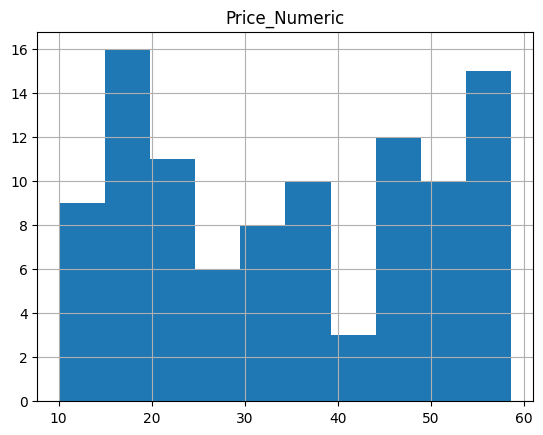

In [ ]:
df_books_dataset.hist()

<Axes: >

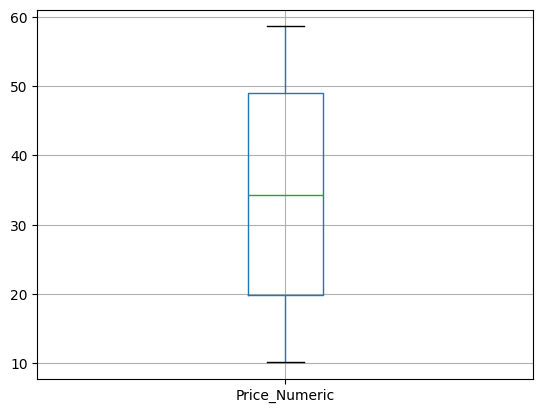

In [ ]:
df_books_dataset.boxplot()

In [ ]:
df_books_dataset['Price_Numeric'].skew()

np.float64(0.05446132220408173)

- 다음은 'Price_Numeric' 열이 정규 분포를 따르는지 검증하기 위한 Shapiro-Wilk 테스트 코드입니다. p-value가 0.05보다 작으면 정규 분포를 따른다는 귀무 가설을 기각합니다.

- Shapiro-Wilk 테스트 결과, p-value가 0.000으로 유의수준 0.05보다 작기 때문에 귀무 가설을 기각합니다. 따라서 'Price_Numeric' 데이터는 정규 분포를 따른다고 보기 어렵습니다.

In [ ]:
from scipy import stats

# Shapiro-Wilk 검정 수행
shapiro_test_statistic, shapiro_p_value = stats.shapiro(df_books_dataset['Price_Numeric'])

print(f"Shapiro-Wilk Test Statistic: {shapiro_test_statistic:.3f}")
print(f"Shapiro-Wilk P-value: {shapiro_p_value:.3f}")

# 결과 해석
alpha = 0.05
if shapiro_p_value > alpha:
    print(f"P-value ({shapiro_p_value:.3f}) > {alpha}, so we fail to reject the null hypothesis. The data appears to be normally distributed.")
else:
    print(f"P-value ({shapiro_p_value:.3f}) <= {alpha}, so we reject the null hypothesis. The data does not appear to be normally distributed.")

Shapiro-Wilk Test Statistic: 0.916
Shapiro-Wilk P-value: 0.000
P-value (0.000) <= 0.05, so we reject the null hypothesis. The data does not appear to be normally distributed.


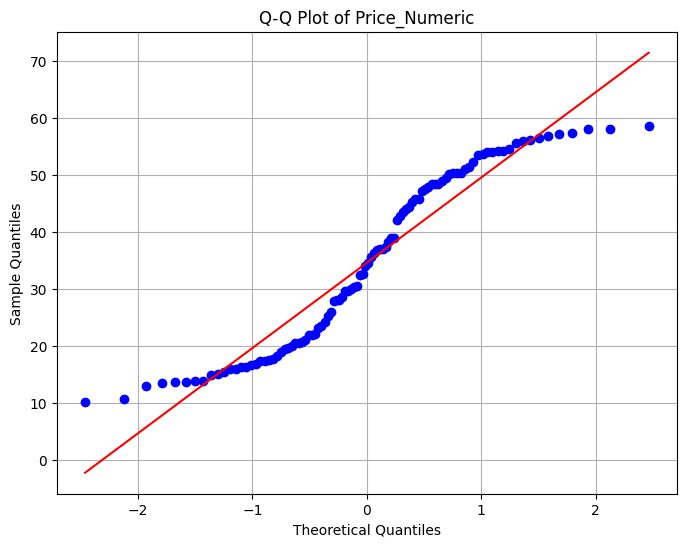

In [ ]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# Q-Q plot 그리기
fig, ax = plt.subplots(figsize=(8, 6))
stats.probplot(df_books_dataset['Price_Numeric'], dist="norm", plot=ax)
ax.set_title('Q-Q Plot of Price_Numeric')
ax.set_xlabel('Theoretical Quantiles')
ax.set_ylabel('Sample Quantiles')
plt.grid(True)
plt.show()

### Q-Q Plot 검증 결과

위 Q-Q plot을 통해 'Price_Numeric' 열의 정규성 여부를 시각적으로 확인할 수 있습니다.

*   **정규 분포를 따르는 경우:** 데이터 포인트들이 대략적으로 45도 참조선(빨간색 선)을 따라 직선 형태로 나타나야 합니다.
*   **정규 분포를 따르지 않는 경우:** 데이터 포인트들이 참조선에서 벗어나 S자 형태, 곡선 형태 등으로 나타나게 됩니다.

현재 Q-Q plot을 보면, 데이터 포인트들이 참조선을 완전히 따르지 않고 양쪽 끝에서 참조선과 멀어지는 경향을 보입니다. 이는 'Price_Numeric' 데이터가 완벽한 정규 분포를 따르지 않음을 시사합니다. 특히, 꼬리 부분이 정규 분포보다 두꺼운(heavy-tailed) 경향을 보이거나 비대칭적인 분포를 가질 수 있습니다.

이러한 시각적 검증 결과는 앞서 수행한 Shapiro-Wilk 검정 결과('Price_Numeric' 데이터가 정규 분포를 따르지 않음)와 일치합니다.